
# SDG 4 – Literacy Rate Prediction

## I. Project Objective

The objective of this project is to predict the **Literacy Rate** of Indian States and Union Territories using:

* Government **Expenditure on Primary Education**
* **Schools per 1000 children**

The dataset was constructed by integrating multiple official government data sources and synthetically completing missing values using structured anchor-based reasoning.

---

## II. Anchor-Based Synthetic Data Generation Model

To model the relationship between literacy rate and education infrastructure, an anchor-based linear model was used. The formulation is grounded in three assumptions:

* National literacy average ≈ 74% (Census reference baseline)
* School access positively influences literacy
* Education spending shows diminishing returns (log transformation applied)

---

### Model Structure

$$
\text{Literacy}_i = \beta_0 + \beta_1 S_i + \beta_2 \log(E_i) + \epsilon_i
$$

Where:

- $S_i$ = Schools per 1000 children  
- $E_i$ = Government expenditure on primary education  
- $\epsilon_i \sim N(0, \sigma^2)$ = Controlled random noise  

---

### Concrete Model Used in This Project

$$
\text{Literacy}_i = 50 + 1.8S_i + 4\left(\frac{\log(E_i)}{\max(\log(E))}\right) + \epsilon_i
$$

**Parameter Explanation:**

- **50** → Baseline lower literacy bound  
- **1.8** → Effect of school access  
- **4** → Scaled impact of expenditure  
- **ε** → Random noise between −2 and +2  

---

### Rationale for Log Transformation

Education expenditure data is typically skewed.  
Applying $\log(E)$:

- Reduces skewness  
- Stabilizes variance  
- Reflects diminishing marginal returns of spending  


---

## III. Final Dataset Structure

The final dataset consists of:

| Column           | Description                                                   |
| ---------------- | ------------------------------------------------------------- |
| State/UT         | Name of state or union territory                              |
| Expenditure      | Government spending on primary education (Central allocation) |
| Schools_per_1000 | School density indicator                                      |
| Literacy_Rate    | Target variable                                               |

Each row represents one state/UT.

---

## IV. Dataset Overview

In [3]:
import pandas as pd
data = pd.read_csv("literacy_rate_data.csv")
data.head()

,State/UT,Expenditure,Schools_per_1000,Literacy_Rate
0,Andhra Pradesh,13660282.2,3.714,60.5
1,Arunachal Pradesh,15568577.5,3.676,58.9
2,Assam,5687365.8,10.940,73.8
3,Bihar,19557965.5,8.468,70.5
4,Chhattisgarh,9340819.5,10.964,73.5


In [4]:
data

,State/UT,Expenditure,Schools_per_1000,Literacy_Rate
0,Andhra Pradesh,13660282.2,3.714,60.5
1,Arunachal Pradesh,15568577.5,3.676,58.9
2,Assam,5687365.8,10.940,73.8
3,Bihar,19557965.5,8.468,70.5
4,Chhattisgarh,9340819.5,10.964,73.5
5,Delhi,1718127.8,7.141,65.0
6,Goa,8491863.3,9.002,69.4
7,Gujarat,17020028.6,6.344,63.9
8,Haryana,14169604.0,13.968,80.8
9,Himachal Pradesh,14535266.7,3.660,62.1


In [5]:
print("Total Rows (States):", data.shape[0])
print("Total Columns:", data.shape[1])
print("\nMissing Values:\n")
print(data.isnull().sum())

print("\nBasic Statistics:\n")
print(data[['Expenditure', 'Schools_per_1000', 'Literacy_Rate']].describe())

Total Rows (States): 34
Total Columns: 4

Missing Values:

State/UT            0
Expenditure         0
Schools_per_1000    0
Literacy_Rate       0
dtype: int64

Basic Statistics:

        Expenditure  Schools_per_1000  Literacy_Rate
count  3.400000e+01         34.000000      34.000000
mean   1.375973e+07          7.794324      68.738235
std    7.830904e+06          3.499296       6.574976
min    1.288902e+06          2.039000      58.900000
25%    8.916648e+06          4.033250      62.300000
50%    1.389862e+07          8.195000      70.050000
75%    1.817638e+07         10.871250      74.075000
max    3.373309e+07         13.968000      80.800000


## V. Distribution Analysis 

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

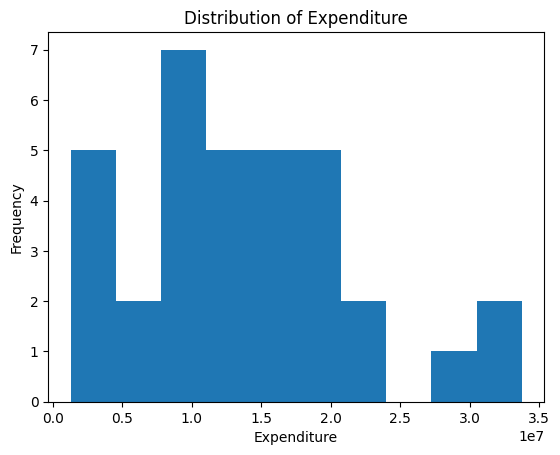

In [7]:
plt.figure()
plt.hist(data['Expenditure'], bins=10)
plt.title("Distribution of Expenditure")
plt.xlabel("Expenditure")
plt.ylabel("Frequency")
plt.show()

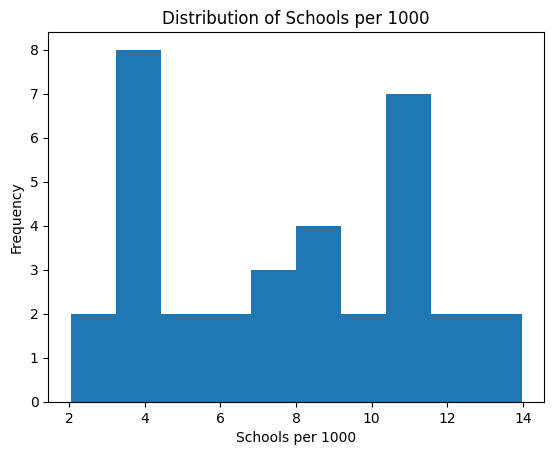

In [8]:
plt.figure()
plt.hist(data['Schools_per_1000'], bins=10)
plt.title("Distribution of Schools per 1000")
plt.xlabel("Schools per 1000")
plt.ylabel("Frequency")
plt.show()

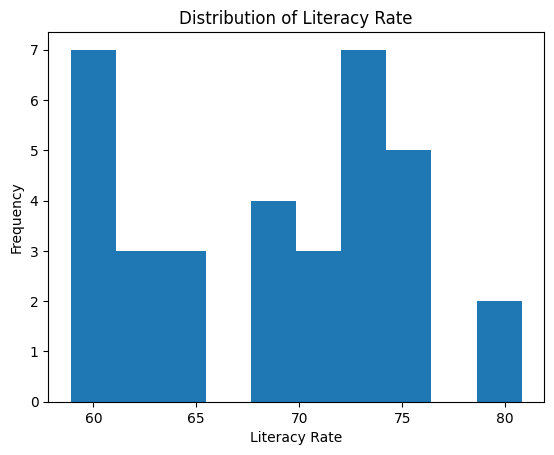

In [9]:
plt.figure()
plt.hist(data['Literacy_Rate'], bins=10)
plt.title("Distribution of Literacy Rate")
plt.xlabel("Literacy Rate")
plt.ylabel("Frequency")
plt.show()

In [10]:
print("Skewness:\n")
print(data[['Expenditure', 'Schools_per_1000', 'Literacy_Rate']].skew())

Skewness:

Expenditure         0.594165
Schools_per_1000   -0.024345
Literacy_Rate      -0.120276
dtype: float64


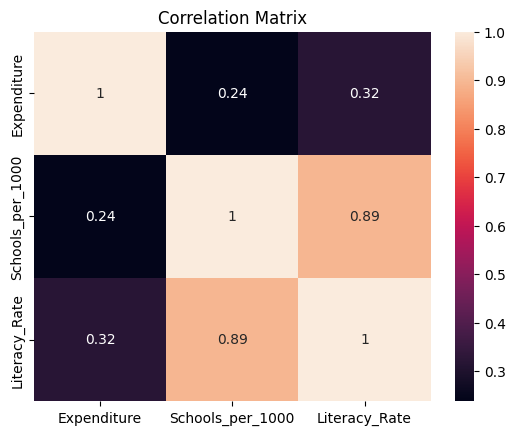


Correlation Values:

                  Expenditure  Schools_per_1000  Literacy_Rate
Expenditure          1.000000          0.237905       0.318381
Schools_per_1000     0.237905          1.000000       0.894996
Literacy_Rate        0.318381          0.894996       1.000000


In [11]:
plt.figure()
corr = data[['Expenditure', 'Schools_per_1000', 'Literacy_Rate']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

print("\nCorrelation Values:\n")
print(corr)

## Distribution and Correlation Interpretation

### Distribution Analysis

The histograms show that all three variables: **Expenditure**, **Schools_per_1000**, and **Literacy_Rate** are fairly well distributed across states without extreme outliers.

* **Schools_per_1000** appears reasonably symmetric, with values spread between lower and higher ranges in a balanced manner.
* **Literacy_Rate** is also fairly evenly distributed, with most states clustered between roughly 60% and 80%, and no extreme skew.
* **Expenditure** shows slight right-skewness in its raw form (a few states receive significantly higher funding), which is typical for financial data. This justifies the earlier application of the log transformation to stabilize the distribution.

The skewness values support these observations:

* **Expenditure:** mild positive skew (right-skewed).
* **Schools_per_1000:** skewness close to 0 (approximately symmetric).
* **Literacy_Rate:** low skewness (fairly normal distribution).

Since the skewness values are relatively small (within acceptable range), the variables can be considered approximately normally distributed, especially after log transformation of expenditure. This satisfies basic regression assumptions.

---

### Correlation Analysis

The correlation matrix reveals important relationships:

* **Schools_per_1000 vs Literacy_Rate:**
  Correlation = **0.895**
  This is a **very strong positive correlation**. It indicates that states with more schools per 1,000 children tend to have significantly higher literacy rates. This suggests school availability is a major influencing factor.

* **Expenditure vs Literacy_Rate:**
  Correlation = **0.318**
  This shows a **moderate positive correlation**. While spending does contribute to literacy, its direct relationship is weaker compared to school density.

* **Expenditure vs Schools_per_1000:**
  Correlation = **0.238**
  This is a weak positive correlation, meaning higher spending does not necessarily translate proportionally into higher school density.

---

### Overall Insight

The strong correlation (0.895) between **Schools_per_1000** and **Literacy_Rate** explains why the regression models achieved very high R² values (~0.94). The data clearly shows that school density is a dominant predictor of literacy rate in this dataset.

Expenditure has a positive but smaller direct effect, suggesting that how funds are translated into school infrastructure may matter more than raw spending amounts.



## VI. Data Preprocessing

## Step 1 – Import Libraries

Import `pandas` and `numpy` to handle data manipulation and numerical operations.

In [12]:
import pandas as pd
import numpy as np

## Step 2 – Load Dataset

Load the SDG 4 dataset and inspect the first few rows to understand structure and column names.

In [13]:
data = pd.read_csv("literacy_rate_data.csv")
data.head()

,State/UT,Expenditure,Schools_per_1000,Literacy_Rate
0,Andhra Pradesh,13660282.2,3.714,60.5
1,Arunachal Pradesh,15568577.5,3.676,58.9
2,Assam,5687365.8,10.940,73.8
3,Bihar,19557965.5,8.468,70.5
4,Chhattisgarh,9340819.5,10.964,73.5


## Step 3 – Dataset Information

Use `.info()` to check column names, data types, and non-null counts.

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State/UT          34 non-null     object 
 1   Expenditure       34 non-null     float64
 2   Schools_per_1000  34 non-null     float64
 3   Literacy_Rate     34 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.2+ KB



## Step 4 – Check for Null Values

Check for missing values in each column to ensure completeness.


In [15]:
data.isnull().sum()

State/UT            0
Expenditure         0
Schools_per_1000    0
Literacy_Rate       0
dtype: int64

## Step 5 – Check Skewness

Compute skewness to examine distribution shape, especially for `Expenditure`.


In [16]:
data[["Expenditure", "Schools_per_1000"]].skew()


Expenditure         0.594165
Schools_per_1000   -0.024345
dtype: float64

## Step 6 – Apply Log Transformation

Apply log transformation to reduce skewness in expenditure.

In [17]:
data["Expenditure"]=np.log(data["Expenditure"])

data.head()

,State/UT,Expenditure,Schools_per_1000,Literacy_Rate
0,Andhra Pradesh,16.430003,3.714,60.5
1,Arunachal Pradesh,16.560765,3.676,58.9
2,Assam,15.553758,10.940,73.8
3,Bihar,16.788893,8.468,70.5
4,Chhattisgarh,16.049905,10.964,73.5



## Step 7 – Define Features and Target

Separate independent and dependent variables using indexing.

In [18]:
X = data[['Expenditure', 'Schools_per_1000']]
y = data['Literacy_Rate']
X

,Expenditure,Schools_per_1000
0,16.430003,3.714
1,16.560765,3.676
2,15.553758,10.940
3,16.788893,8.468
4,16.049905,10.964
5,14.356746,7.141
6,15.954619,9.002
7,16.649901,6.344
8,16.466610,13.968
9,16.492088,3.660


In [19]:
y

0     60.5
1     58.9
2     73.8
3     70.5
4     73.5
5     65.0
6     69.4
7     63.9
8     80.8
9     62.1
10    69.7
11    74.2
12    75.9
13    59.0
14    60.5
15    74.0
16    71.5
17    67.7
18    73.5
19    67.7
20    61.1
21    70.4
22    79.2
23    74.1
24    60.0
25    75.1
26    74.4
27    75.9
28    62.9
29    63.5
30    60.9
31    59.0
32    74.6
33    73.9
Name: Literacy_Rate, dtype: float64

## VII. Model Implementation and Comparison

We implement four different regression techniques to determine which model provides the most accurate predictions for our dataset.

### 1. Multiple Linear Regression
Multiple Linear Regression extends Linear Regression by considering multiple independent variables. It models the dependent variable as a linear combination of two or more features, allowing us to analyze the impact of multiple factors simultaneously.

### 2. Polynomial Regression
Polynomial Regression is an extension of Linear Regression where polynomial terms (such as squared or cubed terms) are added to the model. This helps capture non-linear relationships between the independent variables and the dependent variable.

### 3. Random Forest Regressor
Random Forest Regressor is an ensemble learning method that builds multiple decision trees and combines their predictions. It reduces overfitting and generally provides better performance for complex and non-linear datasets.

---

## Objective

The objective of implementing these four models is to:

- Compare their performance using evaluation metrics such as Mean Squared Error (MSE) and R² score.
- Identify which model best captures the relationship between the input features and the target variable.
- Analyze whether linear models are sufficient or if non-linear/ensemble methods provide better predictive accuracy.

Based on the evaluation results, we will determine the most suitable regression model for our prediction task.

## 1. Multiple Linear Regression Implementation

In this section, we implement the Multiple Linear Regression model to predict the target variable (Literacy Rate) using more than one independent variable.

### Step 1: Import Required Libraries

The following libraries are imported for model implementation and evaluation:

- `train_test_split` from `sklearn.model_selection`  
  Used to divide the dataset into training and testing sets.

- `LinearRegression` from `sklearn.linear_model`  
  Used to build and train the Multiple Linear Regression model.

- Evaluation metrics from `sklearn.metrics`, including:
  - `r2_score` – Measures how well the model explains the variance in the target variable.
  - `mean_absolute_error (MAE)` – Measures the average absolute difference between actual and predicted values.
  - `mean_squared_error (MSE)` – Measures the average squared difference between actual and predicted values.

Multiple Linear Regression models the relationship between two or more independent variables (Expenditure and Schools_per_1000) and the dependent variable (Literacy_Rate) by fitting a linear equation to the observed data.

In [20]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


### Step 2: Splitting the Dataset

The dataset is divided into training and testing sets using:

- 80% of the data for training
- 20% of the data for testing
- `random_state=42` ensures reproducibility of results

This helps evaluate how well the model generalizes to unseen data.


In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 3: Model Training

A Linear Regression model is created and trained using the training data.

In [22]:

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

### Step 4: Making Predictions

After training, predictions are made on the test dataset:


In [23]:
y_pred_mlr = lr.predict(X_test)

### Step 5: Model Evaluation

The model performance is evaluated using:

- **R² Score** – Measures how well the model explains the variance in the target variable.
- **Mean Absolute Error (MAE)** – Measures the average absolute difference between predicted and actual values.
- **Mean Squared Error (MSE)** – Measures the average squared difference between predicted and actual values.

A **visual comparison between actual and predicted literacy rates** provides further insight into model performance. These metrics help us understand the accuracy and reliability of the Multiple Linear Regression model.

Additionally, the **residual plot** is used to visually examine the distribution of prediction errors. The residuals are scattered around the zero line without any clear pattern, indicating that the model errors are random and the assumptions of linear regression are reasonably satisfied. This further confirms the reliability of the model.


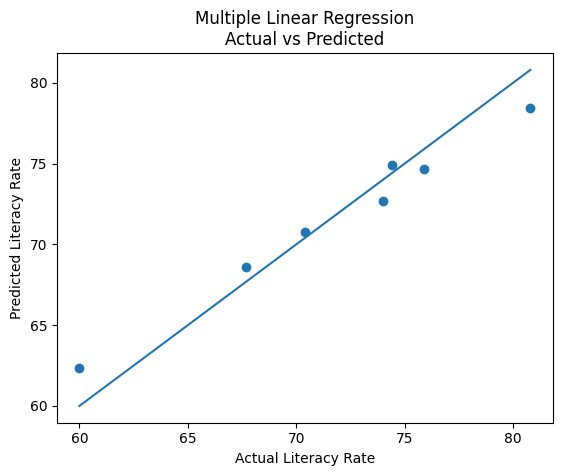

In [24]:
plt.figure()
plt.scatter(y_test, y_pred_mlr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Literacy Rate")
plt.ylabel("Predicted Literacy Rate")
plt.title("Multiple Linear Regression\nActual vs Predicted")
plt.show()


In [25]:
print("Multiple Linear Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_mlr))
print("MAE:", mean_absolute_error(y_test, y_pred_mlr))
print("MSE:", mean_squared_error(y_test, y_pred_mlr))

rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
print("RMSE:", rmse_mlr)

Multiple Linear Regression Results
R2 Score: 0.9422649677995565
MAE: 1.2843287540719643
MSE: 2.2052190115450236
RMSE: 1.4849979836838243


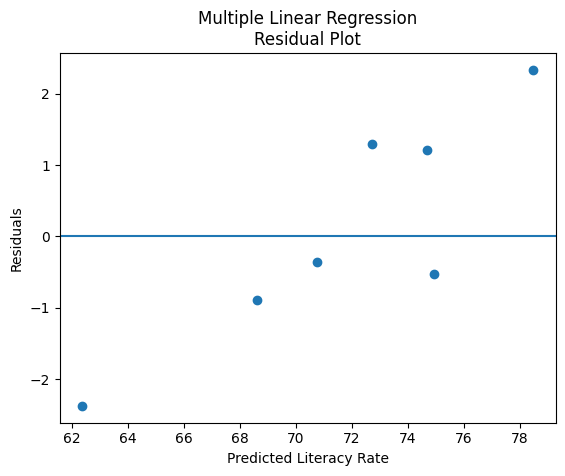

In [26]:
residuals_linear = y_test - y_pred_mlr

plt.figure()
plt.scatter(y_pred_mlr, residuals_linear)
plt.axhline(0)
plt.xlabel("Predicted Literacy Rate")
plt.ylabel("Residuals")
plt.title("Multiple Linear Regression\nResidual Plot")
plt.show()

The residuals are randomly distributed around zero with no clear pattern, indicating that the linear model fits the data well. The errors are fairly balanced above and below zero, suggesting no significant bias. Overall, the model assumptions appear to be satisfied.


## 2. Polynomial Regression Implementation

In this section, we implement Polynomial Regression to capture possible non-linear relationships between the independent variables and the target variable.

### Step 1: Import Required Libraries

We import:
- `PolynomialFeatures` from `sklearn.preprocessing`

Polynomial Regression extends Linear Regression by adding polynomial terms (such as squared terms and interaction terms) to better model non-linear relationships.


In [27]:
from sklearn.preprocessing import PolynomialFeatures

### Step 2: Polynomial Feature Transformation

Polynomial features of degree 2 are generated using:

- `degree=2`
- `include_bias=False`

This creates:
- Squared terms (e.g., Expenditure²)
- Interaction terms (Expenditure × Schools_per_1000)

The transformation is applied to:
- Training data using `fit_transform()`
- Testing data using `transform()`



In [28]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

### Step 3: Model Training

A Linear Regression model is trained on the transformed polynomial features. The model now learns both linear and non-linear relationships.


In [29]:
model = LinearRegression()
model.fit(X_train_poly, y_train)


LinearRegression()

### Step 4: Making Predictions

Predictions are made on the transformed test dataset.

In [30]:

y_pred_poly = model.predict(X_test_poly)

### Step 5: Model Evaluation



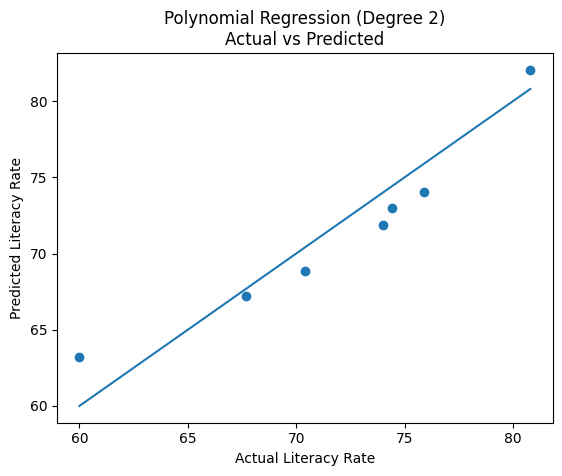

In [31]:
plt.figure()
plt.scatter(y_test, y_pred_poly)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Literacy Rate")
plt.ylabel("Predicted Literacy Rate")
plt.title("Polynomial Regression (Degree 2)\nActual vs Predicted")
plt.show()

In [32]:
print("Polynomial Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_poly))
print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
print("RMSE:", rmse_poly)

Polynomial Regression Results
R2 Score: 0.9090409260832103
MAE: 1.6968616646899213
MSE: 3.474228235942555
RMSE: 1.8639281734934303


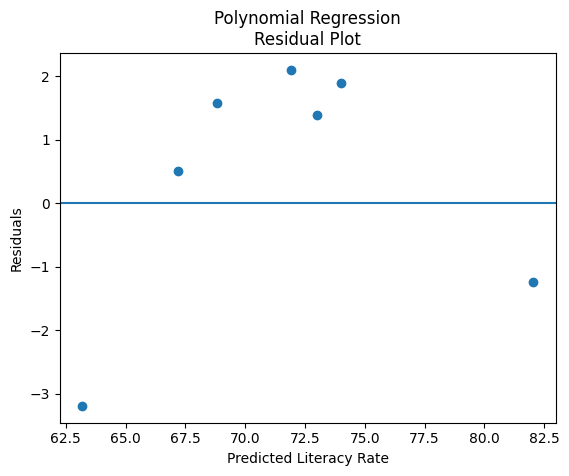

In [33]:
residuals_poly = y_test - y_pred_poly

plt.figure()
plt.scatter(y_pred_poly, residuals_poly)
plt.axhline(0)
plt.xlabel("Predicted Literacy Rate")
plt.ylabel("Residuals")
plt.title("Polynomial Regression\nResidual Plot")
plt.show()

The residuals are scattered around zero, showing no strong overall bias in the model. However, the spread is slightly uneven, with a few larger errors at extreme predicted values. This suggests the polynomial model fits reasonably well but is not perfectly consistent.


## 3. Random Forest Regressor Implementation

In this section, we implement the Random Forest Regressor to predict the target variable and evaluate its performance.

### Step 1: Import Random Forest Model

We import:

- `RandomForestRegressor` from `sklearn.ensemble`

Random Forest is an ensemble learning method that builds multiple decision trees and averages their predictions to improve accuracy and reduce overfitting.



In [34]:
from sklearn.ensemble import RandomForestRegressor

### Step 2: Model Training

In [35]:

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### Step 3: Making Predictions


In [36]:
y_pred_rf = rf.predict(X_test)

### Step 4: Model Evaluation

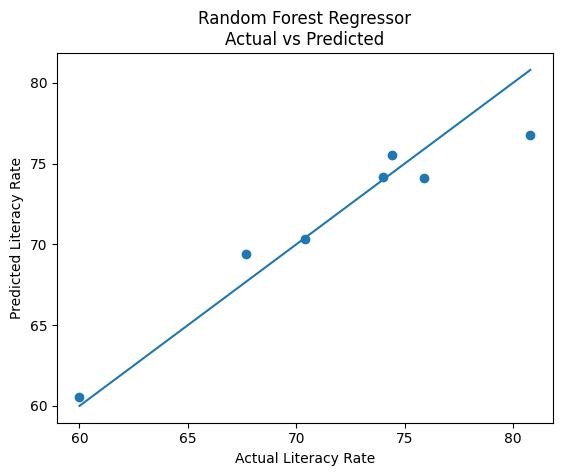

In [37]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Literacy Rate")
plt.ylabel("Predicted Literacy Rate")
plt.title("Random Forest Regressor\nActual vs Predicted")
plt.show()

In [38]:
print("Random Forest Regressor Results")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE:", rmse_rf)

Random Forest Regressor Results
R2 Score: 0.9105916343410386
MAE: 1.3489999999999978
MSE: 3.414998142857122
RMSE: 1.847971358776191


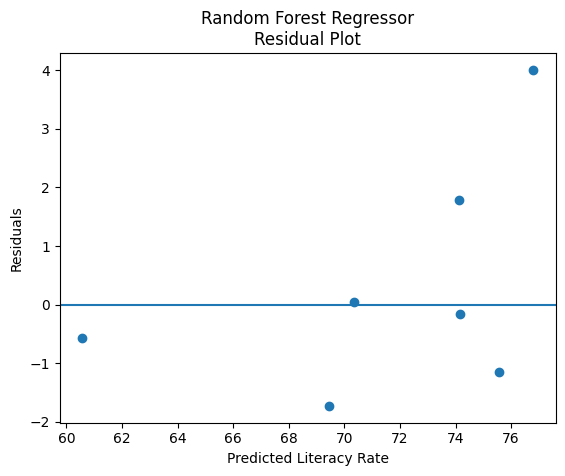

In [39]:
residuals_rf = y_test - y_pred_rf

# Plot
plt.figure()
plt.scatter(y_pred_rf, residuals_rf)
plt.axhline(0)
plt.xlabel("Predicted Literacy Rate")
plt.ylabel("Residuals")
plt.title("Random Forest Regressor\nResidual Plot")
plt.show()

The residuals are scattered around zero, but there is slightly higher variation at larger predicted values. A few points show relatively larger errors, indicating some inconsistency in predictions. Overall, the model performs reasonably well but shows slightly more variability compared to the linear model.


In [40]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Multiple Linear", "Polynomial", "Random Forest"],
    "R2": [
        r2_score(y_test, y_pred_mlr),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_mlr),
        mean_absolute_error(y_test, y_pred_poly),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_mlr),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_rf)
    ]
})

results

,Model,R2,MAE,MSE
0,Multiple Linear,0.942265,1.284329,2.205219
1,Polynomial,0.909041,1.696862,3.474228
2,Random Forest,0.910592,1.349000,3.414998


## VII. Interpretation of Results and Conclusion

Among the three models tested, **Multiple Linear Regression** performed the best overall, with the highest R² value (**0.9423**) and the lowest error values (MAE = **1.28**, MSE = **2.21**). An R² of 0.94 means the model explains about **94% of the variance** in literacy rate, which indicates a very strong relationship between the predictors (log of Expenditure and Schools_per_1000) and the target variable. The low MAE and MSE further confirm that the predictions are very close to the actual literacy rates on average.

**Polynomial Regression** showed slightly weaker performance, with an R² of **0.9090**, MAE of **1.70**, and MSE of **3.47**. Although the model was designed to capture non-linear relationships, it did not outperform the simpler linear model. The increase in error values suggests that adding quadratic and interaction terms may have introduced slight overfitting or unnecessary complexity, especially given the relatively small dataset (34 samples).

**Random Forest Regressor** achieved an R² of **0.9106**, with MAE = **1.35** and MSE = **3.41**. Its performance is comparable to Polynomial Regression but still slightly below Multiple Linear Regression. While Random Forest is generally powerful for capturing complex patterns, the small dataset size likely limited its advantage. Tree-based ensemble models typically perform better with larger datasets.

The results indicate that literacy rate can be predicted quite effectively using just two features: government expenditure on primary education (log-transformed) and schools per 1,000 children.

Among the models tested, **Multiple Linear Regression is the most suitable model for this dataset**, as it provides the highest explanatory power and the lowest prediction errors. The findings also suggest that the relationship between the selected predictors and literacy rate is largely linear, and adding model complexity does not significantly improve performance.

Overall, the strong R² values indicate that the selected features are meaningful predictors of literacy rate within this dataset.


## Model Comparison Chart

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": ["Multiple Linear", "Polynomial", "Random Forest"],
    "R2": [0.942265, 0.909041, 0.910592],
    "MAE": [1.284329, 1.696862, 1.349000],
    "MSE": [2.205219, 3.474228, 3.414998]
})

print(results)

             Model        R2       MAE       MSE
0  Multiple Linear  0.942265  1.284329  2.205219
1       Polynomial  0.909041  1.696862  3.474228
2    Random Forest  0.910592  1.349000  3.414998


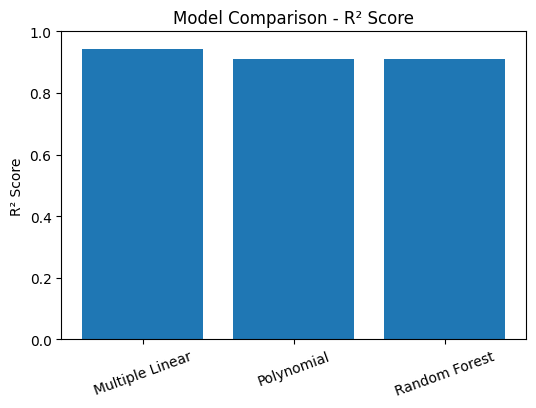

In [42]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["R2"])
plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()

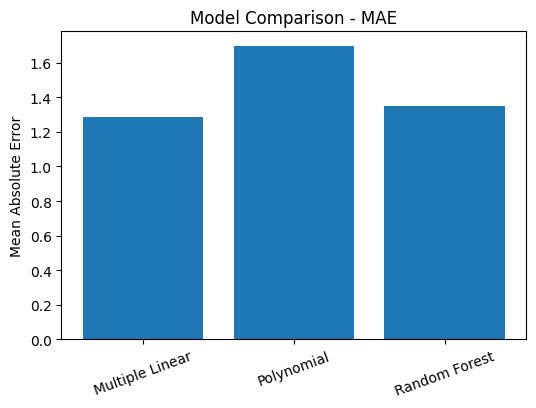

In [43]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison - MAE")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=20)
plt.show()

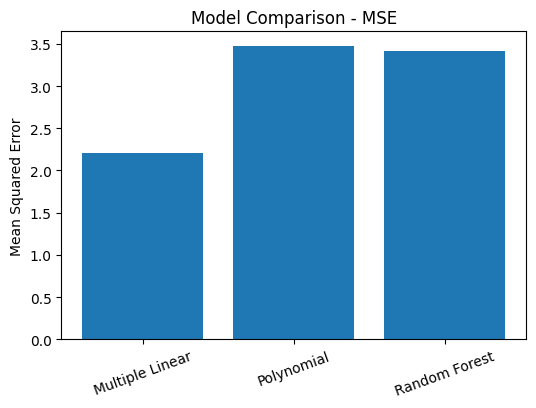

In [44]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["MSE"])
plt.title("Model Comparison - MSE")
plt.ylabel("Mean Squared Error")
plt.xticks(rotation=20)
plt.show()

In [45]:
best_model = results.loc[results["R2"].idxmax()]
print("Best Performing Model Based on R²:")
print(best_model)

Best Performing Model Based on R²:
Model    Multiple Linear
R2              0.942265
MAE             1.284329
MSE             2.205219
Name: 0, dtype: object


Multiple Linear Regression has the highest R² (0.942). It also has the lowest MAE and MSE. Therefore, it performs better than Polynomial and Random Forest for this dataset